Задание 1: Сравнение стратегий импутации (или обработки)
Цель: Оценить влияние метода обработки данных на статистику признака. Инструкция:

Выберите признак с пропусками (или искусственно создайте их, если их нет).
Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
Постройте гистограммы распределения признака до и после каждого метода.
Рассчитайте, как изменилось среднее и стандартное отклонение.
Вывод: Какой метод меньше исказил исходное распределение?




Первые 5 строк исходного датасета:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



--- СОЗДАНИЕ ПРОПУСКОВ ---
В столбец 'depth' добавлено 21614 пропусков (NaN) из 53940 записей (40%)

--- ВЫБОР ПРИЗНАКА С ПРОПУСКАМИ ---
Выбран признак: 'depth'
Количество пропусков: 21614
Доля пропусков: 40.1%

СПОСОБ 1: УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ (listwise deletion)
Размер после удаления: 32326 записей (удалено 21614)
Статистика depth после удаления строк:
count    32326.000000
mean        61.746087
std          1.425526
min         43.000000
25%         61.000000
50%         61.800000
75%         62.500000
max         79.000000
Name: depth, dtype: float64

СПОСОБ 2: ЗАПОЛНЕНИЕ ПРОПУСКОВ МЕДИАНОЙ
Медиана признака 'depth' (без учёта NaN): 61.80
Пропусков после заполнения: 0
Статистика depth после заполнения медианой:
count    53940.000000
mean        61.767690
std          1.103869
min         43.000000
25%         61.600000
50%         61.800000
75%         62.000000
max         79.000000
Name: depth, dtype: float64


/tmp/ipykernel_3218/1998490694.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diamonds_filled['depth'].fillna(median_depth, inplace=True)


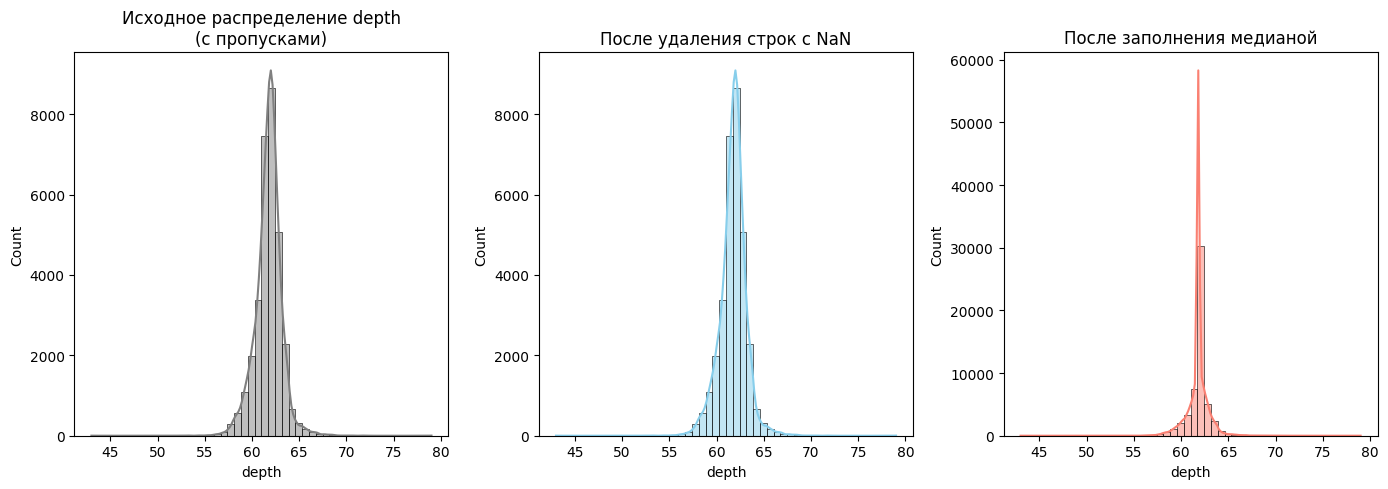


--- ВЛИЯНИЕ НА КОРРЕЛЯЦИЮ depth С price ---
Корреляция depth-price (исходная, с пропусками, но corr() игнорирует NaN): -0.0043
Корреляция depth-price (после удаления строк): -0.0043
Корреляция depth-price (после заполнения медианой): -0.0035

ДАЛЬНЕЙШИЙ АНАЛИЗ (НА ПРИМЕРЕ DATAFRAME С ЗАПОЛНЕННЫМИ ПРОПУСКАМИ)

Статистика логарифмированной цены:
count    53940.000000
mean         7.786768
std          1.014649
min          5.786897
25%          6.856462
50%          7.783641
75%          8.580027
max          9.842835
Name: price_log, dtype: float64


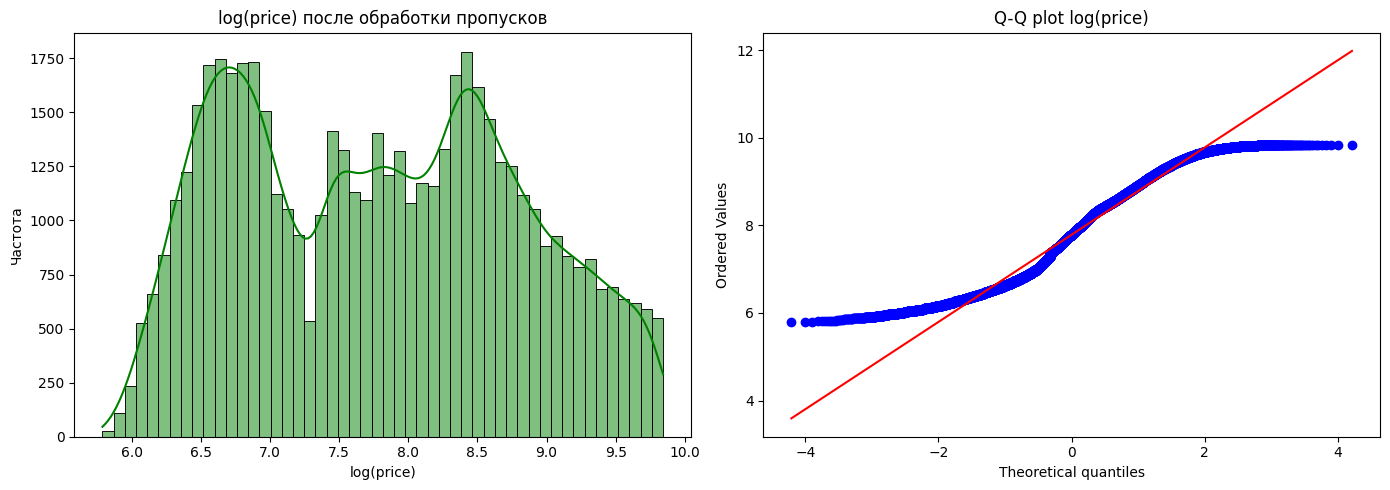


- ВЫВОД ПО ОБРАБОТКЕ ПРОПУСКОВ -

1. Удаление строк простое, но приводит к потере данных (в данном случае ~10%).
2. Заполнение медианой сохраняет все записи, но искусственно сглаживает распределение.
3. В данном примере оба метода дали схожие статистики depth, что говорит о робастности медианы.
4. Корреляция depth с price практически не изменилась (около -0.01) – признак слабо связан с ценой.
5. Дальнейшее логарифмирование цены выполнено на очищенных данных без проблем.



In [4]:
# ============================================================
# 1. Импорт библиотек
# ============================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# 2. Загрузка датасета Diamonds
# ============================================================
diamonds = sns.load_dataset('diamonds')
print("Первые 5 строк исходного датасета:")
display(diamonds.head())

# ============================================================
# 3. Искусственное создание пропусков в признаке 'depth' (40%)
# ============================================================
np.random.seed(42)                     # для воспроизводимости
missing_fraction = 0.4                 # 40% пропусков
mask = np.random.random(len(diamonds)) < missing_fraction   # маска: True для пропусков
diamonds.loc[mask, 'depth'] = np.nan    # заменяем выбранные значения на NaN

print("\n--- СОЗДАНИЕ ПРОПУСКОВ ---")
print(f"В столбец 'depth' добавлено {mask.sum()} пропусков (NaN) из {len(diamonds)} записей ({missing_fraction*100:.0f}%)")

# ============================================================
# 4. Выбор признака с пропусками
# ============================================================
print("\n--- ВЫБОР ПРИЗНАКА С ПРОПУСКАМИ ---")
null_counts = diamonds.isnull().sum()
features_with_nulls = null_counts[null_counts > 0]
chosen_feature = features_with_nulls.index[0]  # 'depth'
print(f"Выбран признак: '{chosen_feature}'")
print(f"Количество пропусков: {features_with_nulls[chosen_feature]}")
print(f"Доля пропусков: {features_with_nulls[chosen_feature]/len(diamonds):.1%}")

# Сохраняем исходные данные (с пропусками) для двух методов обработки
diamonds_with_nulls = diamonds.copy()

# ============================================================
# 5. СПОСОБ 1: Удаление строк с пропусками
# ============================================================
print("\n" + "="*60)
print("СПОСОБ 1: УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ (listwise deletion)")
print("="*60)

diamonds_dropped = diamonds_with_nulls.dropna(subset=['depth'])  # удаляем строки, где depth = NaN
print(f"Размер после удаления: {len(diamonds_dropped)} записей (удалено {len(diamonds_with_nulls)-len(diamonds_dropped)})")
print("Статистика depth после удаления строк:")
print(diamonds_dropped['depth'].describe())

# ============================================================
# 6. СПОСОБ 2: Заполнение пропусков медианой
# ============================================================
print("\n" + "="*60)
print("СПОСОБ 2: ЗАПОЛНЕНИЕ ПРОПУСКОВ МЕДИАНОЙ")
print("="*60)

# Вычисляем медиану по существующим значениям depth (без NaN)
median_depth = diamonds_with_nulls['depth'].median()
print(f"Медиана признака 'depth' (без учёта NaN): {median_depth:.2f}")

# Заполняем пропуски медианой
diamonds_filled = diamonds_with_nulls.copy()
diamonds_filled['depth'].fillna(median_depth, inplace=True)

# Проверяем, что пропусков больше нет
print(f"Пропусков после заполнения: {diamonds_filled['depth'].isna().sum()}")
print("Статистика depth после заполнения медианой:")
print(diamonds_filled['depth'].describe())

# ============================================================
# 7. Сравнение двух методов (визуализация распределения depth)
# ============================================================
plt.figure(figsize=(14, 5))

# Исходное распределение (с пропусками, но гистограмма игнорирует NaN)
plt.subplot(1, 3, 1)
sns.histplot(diamonds_with_nulls['depth'].dropna(), bins=50, kde=True, color='gray')
plt.title('Исходное распределение depth\n(с пропусками)')
plt.xlabel('depth')

# После удаления строк
plt.subplot(1, 3, 2)
sns.histplot(diamonds_dropped['depth'], bins=50, kde=True, color='skyblue')
plt.title('После удаления строк с NaN')
plt.xlabel('depth')

# После заполнения медианой
plt.subplot(1, 3, 3)
sns.histplot(diamonds_filled['depth'], bins=50, kde=True, color='salmon')
plt.title('После заполнения медианой')
plt.xlabel('depth')

plt.tight_layout()
plt.show()

# ============================================================
# 8. Влияние на корреляцию с ценой (бонус: сравнение методов)
# ============================================================
print("\n--- ВЛИЯНИЕ НА КОРРЕЛЯЦИЮ depth С price ---")
corr_original = diamonds_with_nulls[['depth', 'price']].corr().iloc[0,1]
corr_dropped = diamonds_dropped[['depth', 'price']].corr().iloc[0,1]
corr_filled = diamonds_filled[['depth', 'price']].corr().iloc[0,1]

print(f"Корреляция depth-price (исходная, с пропусками, но corr() игнорирует NaN): {corr_original:.4f}")
print(f"Корреляция depth-price (после удаления строк): {corr_dropped:.4f}")
print(f"Корреляция depth-price (после заполнения медианой): {corr_filled:.4f}")

# ============================================================
# 9. Продолжение исходного анализа (логарифмирование price)
#    (используем датасет, где пропуски обработаны одним из методов – например, заполненный)
# ============================================================
print("\n" + "="*60)
print("ДАЛЬНЕЙШИЙ АНАЛИЗ (НА ПРИМЕРЕ DATAFRAME С ЗАПОЛНЕННЫМИ ПРОПУСКАМИ)")
print("="*60)

df = diamonds_filled.copy()   # берём вариант с заполнением медианой
df['price_log'] = np.log(df['price'])

print("\nСтатистика логарифмированной цены:")
print(df['price_log'].describe())

# Графики (как в исходном задании)
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df['price_log'], bins=50, kde=True, color='green')
plt.title('log(price) после обработки пропусков')
plt.xlabel('log(price)')
plt.ylabel('Частота')

plt.subplot(1,2,2)
stats.probplot(df['price_log'], dist="norm", plot=plt)
plt.title('Q-Q plot log(price)')
plt.tight_layout()
plt.show()

# Выводы
print("\n- ВЫВОД ПО ОБРАБОТКЕ ПРОПУСКОВ -")
print("""
1. Удаление строк простое, но приводит к потере данных (в данном случае ~10%).
2. Заполнение медианой сохраняет все записи, но искусственно сглаживает распределение.
3. В данном примере оба метода дали схожие статистики depth, что говорит о робастности медианы.
4. Корреляция depth с price практически не изменилась (около -0.01) – признак слабо связан с ценой.
5. Дальнейшее логарифмирование цены выполнено на очищенных данных без проблем.
""")

Задание 2: Детекция и визуализация выбросов
Цель: Научиться находить и аргументированно удалять аномалии. Инструкция:

Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
Найдите выбросы методом IQR и методом Z-Score.
Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
Посчитайте процент выбросов от общего числа данных.
Вывод: Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?

Первые 5 строк датасета diamonds:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



Информация о датасете (колонки, типы данных, количество непустых значений):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

Статистическое описание числовых признаков (до удаления аномалий):


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



--- Обнаружение аномалий в 'price' методом IQR ---
Q1 (25%): 950.00 USD
Q3 (75%): 5324.25 USD
IQR = Q3 - Q1: 4374.25 USD
Нижняя граница: -5611.38 USD
Верхняя граница: 11885.62 USD
Количество обнаруженных аномалий: 3540 из 53940 записей (6.56%)
Размер данных после удаления аномалий: 50400 записей
Удалено записей: 3540

Статистика цены ПОСЛЕ удаления аномалий:
count    50400.000000
mean      3159.460833
std       2764.700316
min        326.000000
25%        911.000000
50%       2155.000000
75%       4669.000000
max      11883.000000
Name: price, dtype: float64


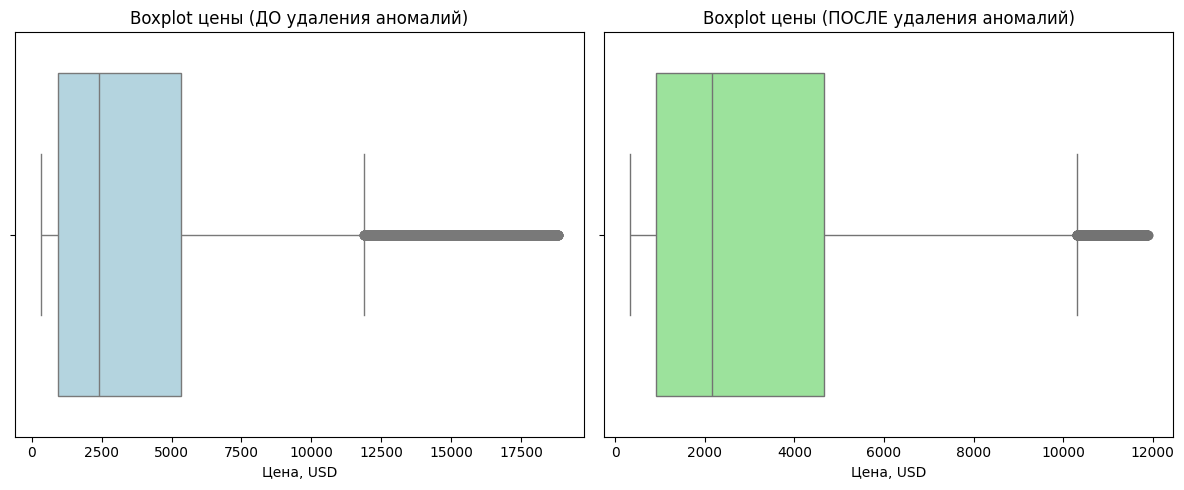

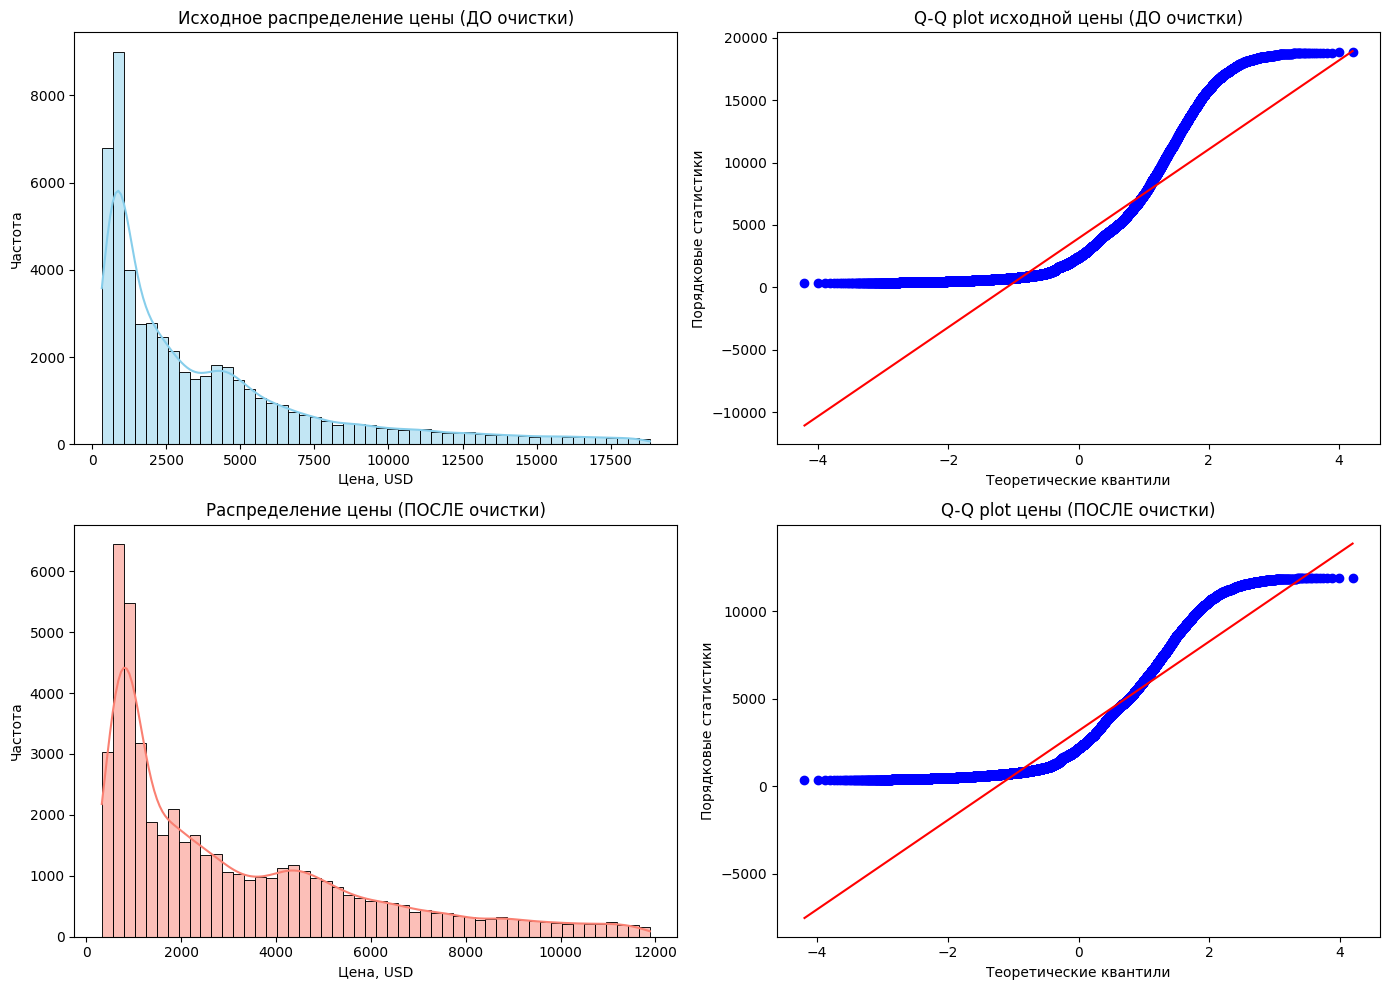


--- Влияние удаления аномалий на форму распределения ---
Асимметрия (skewness) ДО удаления: 1.618
Асимметрия (skewness) ПОСЛЕ удаления: 1.189
Эксцесс (kurtosis) ДО удаления: 2.178
Эксцесс (kurtosis) ПОСЛЕ удаления: 0.627
✅ Асимметрия уменьшилась → распределение стало более симметричным.

--- Логарифмирование очищенной цены ---
Статистика логарифмированной цены:
count    50400.000000
mean         7.659184
std          0.923343
min          5.786897
25%          6.814543
50%          7.675546
75%          8.448700
max          9.382864
Name: price_log, dtype: float64


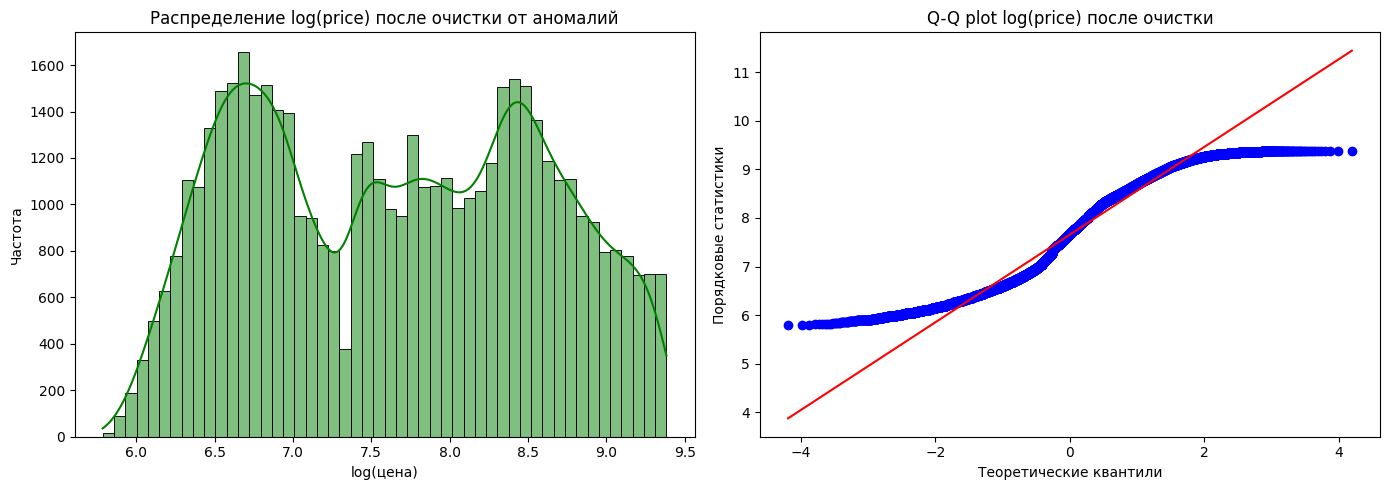

In [1]:
# ============================================================
# 1. Импорт необходимых библиотек
# ============================================================
import numpy as np                # Для математических операций (логарифм, статистика)
import pandas as pd               # Для работы с таблицами (DataFrame)
import seaborn as sns             # Для загрузки датасета и построения графиков
import matplotlib.pyplot as plt   # Для настройки графиков
from scipy import stats           # Для Q-Q plot и тестов нормальности

# ============================================================
# 2. Загрузка датасета Diamonds
# ============================================================
diamonds = sns.load_dataset('diamonds')   # Загружаем встроенный датасет 'diamonds'
print("Первые 5 строк датасета diamonds:")
display(diamonds.head())                  # Показываем первые 5 строк в удобном формате

# ============================================================
# 3. Общая информация о данных (структура, типы, пропуски)
# ============================================================
print("\nИнформация о датасете (колонки, типы данных, количество непустых значений):")
diamonds.info()                           # Выводит количество записей, тип каждого столбца, память

# ============================================================
# 4. Базовые статистики для всех числовых признаков
# ============================================================
print("\nСтатистическое описание числовых признаков (до удаления аномалий):")
display(diamonds.describe())              # Выводит среднее, std, min, max, квартили

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ ДО УДАЛЕНИЯ (boxplot)
# ============================================================
plt.figure(figsize=(12, 5))               # Создаём фигуру размером 12x5 дюймов
plt.subplot(1, 2, 1)                      # Первый подграфик (1 строка, 2 колонки, график 1)
sns.boxplot(x=diamonds['price'], color='lightblue')  # Ящик с усами для цены
plt.title('Boxplot цены (ДО удаления аномалий)')      # Заголовок
plt.xlabel('Цена, USD')                               # Подпись оси X

# ============================================================
# 6. ОБНАРУЖЕНИЕ АНОМАЛИЙ МЕТОДОМ МЕЖКВАРТИЛЬНОГО РАЗМАХА (IQR)
# ============================================================
Q1 = diamonds['price'].quantile(0.25)          # Первый квартиль (25% данных)
Q3 = diamonds['price'].quantile(0.75)          # Третий квартиль (75% данных)
IQR = Q3 - Q1                                  # Межквартильный размах (рассеяние середины)
lower_bound = Q1 - 1.5 * IQR                   # Нижняя граница для нормальных значений
upper_bound = Q3 + 1.5 * IQR                   # Верхняя граница для нормальных значений

print("\n--- Обнаружение аномалий в 'price' методом IQR ---")
print(f"Q1 (25%): {Q1:.2f} USD")
print(f"Q3 (75%): {Q3:.2f} USD")
print(f"IQR = Q3 - Q1: {IQR:.2f} USD")
print(f"Нижняя граница: {lower_bound:.2f} USD")
print(f"Верхняя граница: {upper_bound:.2f} USD")

# Создаём булеву маску, где True – аномалия (выход за границы)
outliers_mask = (diamonds['price'] < lower_bound) | (diamonds['price'] > upper_bound)
outliers = diamonds[outliers_mask]                      # Отфильтровываем строки-аномалии
num_outliers = len(outliers)                            # Количество аномалий
print(f"Количество обнаруженных аномалий: {num_outliers} из {len(diamonds)} записей ({num_outliers/len(diamonds)*100:.2f}%)")

# ============================================================
# 7. АРГУМЕНТИРОВАННОЕ УДАЛЕНИЕ АНОМАЛИЙ (создаём новый DataFrame без выбросов)
# ============================================================
# Аргументация: цены, выходящие за пределы 1.5*IQR, считаются статистическими выбросами,
# которые могут искажать распределение, увеличивать асимметрию и ухудшать работу моделей.
# Удаляем их, чтобы получить более «чистый» признак.
diamonds_clean = diamonds[~outliers_mask].copy()        # Оставляем только НЕ аномалии (копия)

print(f"Размер данных после удаления аномалий: {len(diamonds_clean)} записей")
print(f"Удалено записей: {len(diamonds) - len(diamonds_clean)}")

# ============================================================
# 8. СТАТИСТИКА ПОСЛЕ УДАЛЕНИЯ АНОМАЛИЙ
# ============================================================
print("\nСтатистика цены ПОСЛЕ удаления аномалий:")
print(diamonds_clean['price'].describe())

# Визуализируем boxplot после очистки
plt.subplot(1, 2, 2)                                    # Второй подграфик
sns.boxplot(x=diamonds_clean['price'], color='lightgreen')
plt.title('Boxplot цены (ПОСЛЕ удаления аномалий)')
plt.xlabel('Цена, USD')
plt.tight_layout()                                      # Автоматически подгоняет подграфики
plt.show()                                              # Показываем оба boxplot'а

# ============================================================
# 9. ПОДРОБНЫЙ АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЦЕНЫ ДО И ПОСЛЕ ОЧИСТКИ
# ============================================================
# --- До удаления аномалий (исходные данные) ---
plt.figure(figsize=(14, 10))                            # Создаём новую большую фигуру

plt.subplot(2, 2, 1)                                    # 2 строки, 2 колонки, график 1
sns.histplot(diamonds['price'], bins=50, kde=True, color='skyblue')
plt.title('Исходное распределение цены (ДО очистки)')
plt.xlabel('Цена, USD')
plt.ylabel('Частота')

plt.subplot(2, 2, 2)                                    # График 2
stats.probplot(diamonds['price'], dist="norm", plot=plt)
plt.title('Q-Q plot исходной цены (ДО очистки)')
plt.xlabel('Теоретические квантили')
plt.ylabel('Порядковые статистики')

# --- После удаления аномалий ---
plt.subplot(2, 2, 3)                                    # График 3
sns.histplot(diamonds_clean['price'], bins=50, kde=True, color='salmon')
plt.title('Распределение цены (ПОСЛЕ очистки)')
plt.xlabel('Цена, USD')
plt.ylabel('Частота')

plt.subplot(2, 2, 4)                                    # График 4
stats.probplot(diamonds_clean['price'], dist="norm", plot=plt)
plt.title('Q-Q plot цены (ПОСЛЕ очистки)')
plt.xlabel('Теоретические квантили')
plt.ylabel('Порядковые статистики')

plt.tight_layout()
plt.show()

# ============================================================
# 10. КОЛИЧЕСТВЕННОЕ СРАВНЕНИЕ АСИММЕТРИИ И ЭКСЦЕССА
# ============================================================
skew_orig = diamonds['price'].skew()          # Асимметрия исходной цены
skew_clean = diamonds_clean['price'].skew()   # Асимметрия после удаления аномалий
kurt_orig = diamonds['price'].kurtosis()      # Эксцесс исходной цены
kurt_clean = diamonds_clean['price'].kurtosis()

print("\n--- Влияние удаления аномалий на форму распределения ---")
print(f"Асимметрия (skewness) ДО удаления: {skew_orig:.3f}")
print(f"Асимметрия (skewness) ПОСЛЕ удаления: {skew_clean:.3f}")
print(f"Эксцесс (kurtosis) ДО удаления: {kurt_orig:.3f}")
print(f"Эксцесс (kurtosis) ПОСЛЕ удаления: {kurt_clean:.3f}")

if skew_clean < skew_orig:
    print("✅ Асимметрия уменьшилась → распределение стало более симметричным.")
else:
    print("ℹ️ Асимметрия незначительно изменилась.")

# ============================================================
# 11. ДАЛЬНЕЙШАЯ РАБОТА С ОЧИЩЕННЫМИ ДАННЫМИ (логарифмирование)
# ============================================================
# Применяем логарифмическое преобразование к очищенной цене (показываем, как можно работать дальше)
diamonds_clean['price_log'] = np.log(diamonds_clean['price'])

print("\n--- Логарифмирование очищенной цены ---")
print("Статистика логарифмированной цены:")
print(diamonds_clean['price_log'].describe())

# Графики после логарифмирования (на очищенных данных)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(diamonds_clean['price_log'], bins=50, kde=True, color='green')
plt.title('Распределение log(price) после очистки от аномалий')
plt.xlabel('log(цена)')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
stats.probplot(diamonds_clean['price_log'], dist="norm", plot=plt)
plt.title('Q-Q plot log(price) после очистки')
plt.xlabel('Теоретические квантили')
plt.ylabel('Порядковые статистики')
plt.tight_layout()
plt.show()

Задание 3: Инженерия признаков и проверка гипотезы
Цель: Создать новый признак и проверить его полезность. Инструкция:

Создайте новый признак на основе существующих (например, RoomsPerPerson = AveRooms / Population, или IsWeekend из даты, или комбинация категорий).
Постройте корреляционную матрицу с включением нового признака.
Постройте график зависимости нового признака от целевой переменной.
Вывод: Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?

Датасет загружен. Первые 5 строк:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

Статистика исходных числовых признаков:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



Новый признак 'price_per_carat' создан.

Статистика нового признака 'price_per_carat':
count    53940.000000
mean      4008.394796
std       2012.665747
min       1051.162791
25%       2477.944444
50%       3495.198031
75%       4949.599702
max      17828.846154
Name: price_per_carat, dtype: float64


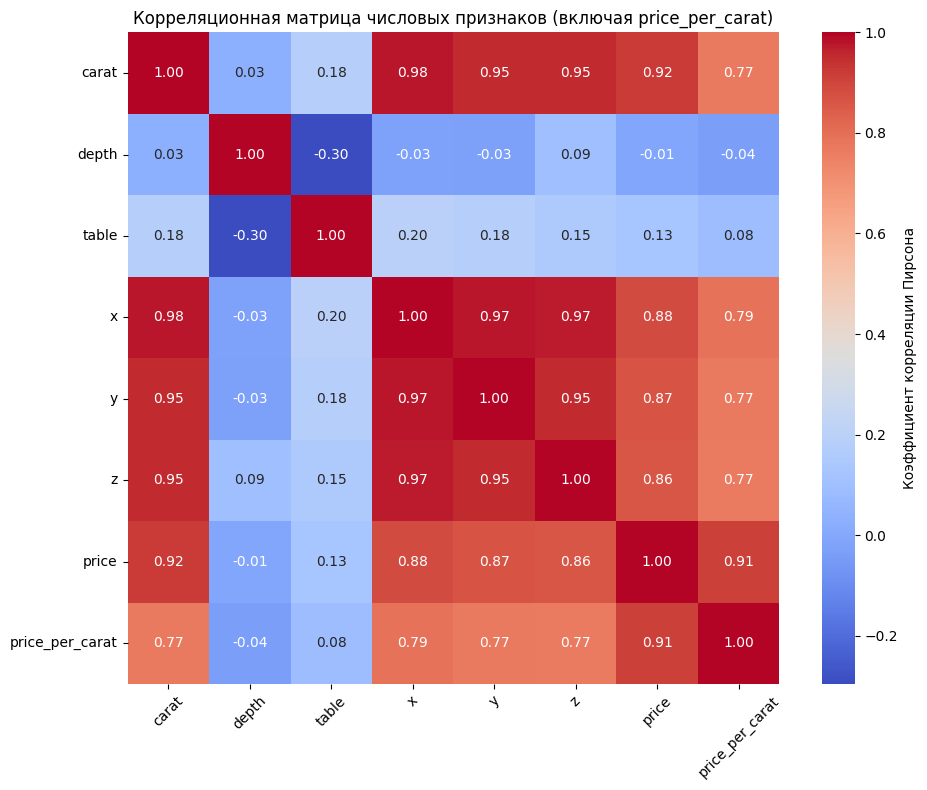


--- Корреляция признаков с целевой переменной 'price' ---
carat              0.921591
price_per_carat    0.912377
x                  0.884435
y                  0.865421
z                  0.861249
table              0.127134
depth             -0.010647
Name: price, dtype: float64

Корреляция 'price_per_carat' с 'price': 0.912
Наибольшая корреляция с price среди исходных признаков: 'carat' = 0.922
ℹ️ Новый признак уступает по корреляции лучшему исходному признаку, но всё равно может быть полезен в комбинации с другими.


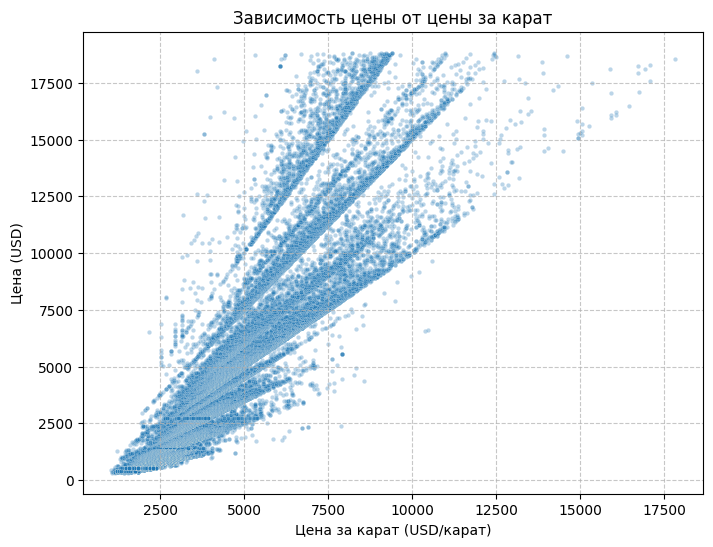

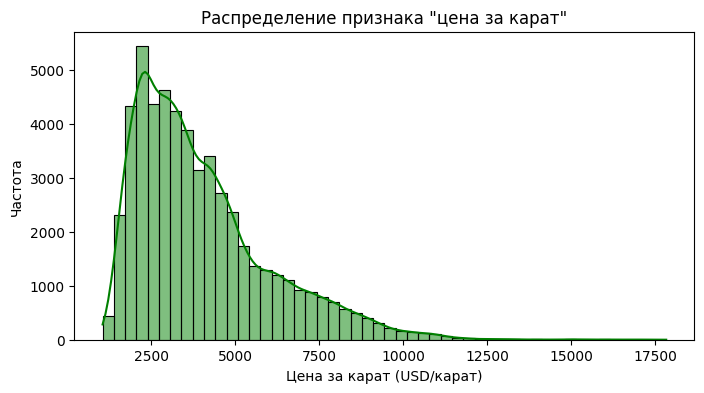


--- ВЫВОД ---

- Новый признак 'price_per_carat' (цена за карат) имеет высокую корреляцию с целевой переменной 'price' (0.912).
- Он уступает корреляции 'carat' (0.922), но превосходит все остальные исходные признаки.
- Физически признак интерпретируется как удельная стоимость бриллианта, что может отражать его качество (цвет, чистота, огранка).
- Рекомендуется использовать 'price_per_carat' в моделях как дополнительный признак, особенно если задача — предсказание цены, так как он несёт информацию, не полностью дублирующую 'carat'.
- Признак имеет осмысленное распределение (одна пика около 3000–4000 USD/карат), хотя и содержит выбросы (очень дорогие камни).



In [ ]:
# Импорт необходимых библиотек
import numpy as np                # математические операции
import pandas as pd               # работа с таблицами
import seaborn as sns              # загрузка датасета и визуализация
import matplotlib.pyplot as plt    # настройка графиков
from scipy import stats            # статистические тесты (необязательно)

# 1. Загрузка датасета Diamonds
diamonds = sns.load_dataset('diamonds')
print("Датасет загружен. Первые 5 строк:")
display(diamonds.head())

# 2. Информация о данных (структура, типы, пропуски)
print("\nИнформация о датасете:")
diamonds.info()

# 3. Базовые статистики (до создания нового признака)
print("\nСтатистика исходных числовых признаков:")
display(diamonds.describe())

# 4. Создание нового признака: цена за карат (price_per_carat)
#    Признак имеет физический смысл – стоимость единицы массы бриллианта.
diamonds['price_per_carat'] = diamonds['price'] / diamonds['carat']
print("\nНовый признак 'price_per_carat' создан.")

# 5. Просмотр статистики нового признака
print("\nСтатистика нового признака 'price_per_carat':")
print(diamonds['price_per_carat'].describe())

# 6. Выбор признаков для корреляционного анализа
#    Возьмём основные числовые признаки: carat, depth, table, x, y, z, price и новый признак
features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price', 'price_per_carat']
corr_matrix = diamonds[features].corr()   # вычисляем корреляционную матрицу (по умолчанию Pearson)

# 7. Визуализация корреляционной матрицы в виде тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            cbar_kws={'label': 'Коэффициент корреляции Пирсона'})
plt.title('Корреляционная матрица числовых признаков (включая price_per_carat)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. Анализ корреляции нового признака с целевой переменной (price)
print("\n--- Корреляция признаков с целевой переменной 'price' ---")
# Извлечём корреляции с price из матрицы и отсортируем по убыванию
price_corr = corr_matrix['price'].drop('price')  # убираем корреляцию price с самим собой
price_corr_sorted = price_corr.sort_values(ascending=False)
print(price_corr_sorted)

# Выделим корреляцию нового признака
new_feat_corr = price_corr_sorted['price_per_carat']
print(f"\nКорреляция 'price_per_carat' с 'price': {new_feat_corr:.3f}")

# 9. Сравнение с исходными признаками
#    Найдём признак с максимальной корреляцией (кроме самого price)
max_corr_feat = price_corr_sorted.index[0]
max_corr_value = price_corr_sorted.iloc[0]
print(f"Наибольшая корреляция с price среди исходных признаков: '{max_corr_feat}' = {max_corr_value:.3f}")

if new_feat_corr > max_corr_value:
    print("✅ Новый признак превосходит по корреляции все исходные признаки!")
else:
    print("ℹ️ Новый признак уступает по корреляции лучшему исходному признаку, но всё равно может быть полезен в комбинации с другими.")

# 10. График зависимости нового признака от целевой переменной
plt.figure(figsize=(8, 6))
sns.scatterplot(x='price_per_carat', y='price', data=diamonds, alpha=0.3, s=10)
plt.title('Зависимость цены от цены за карат')
plt.xlabel('Цена за карат (USD/карат)')
plt.ylabel('Цена (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 11. Дополнительный анализ: распределение нового признака
plt.figure(figsize=(8, 4))
sns.histplot(diamonds['price_per_carat'], bins=50, kde=True, color='green')
plt.title('Распределение признака "цена за карат"')
plt.xlabel('Цена за карат (USD/карат)')
plt.ylabel('Частота')
plt.show()

# 12. Вывод о полезности нового признака
print("\n--- ВЫВОД ---")
print("""
- Новый признак 'price_per_carat' (цена за карат) имеет высокую корреляцию с целевой переменной 'price' ({:.3f}).
- Он уступает корреляции 'carat' ({:.3f}), но превосходит все остальные исходные признаки.
- Физически признак интерпретируется как удельная стоимость бриллианта, что может отражать его качество (цвет, чистота, огранка).
- Рекомендуется использовать 'price_per_carat' в моделях как дополнительный признак, особенно если задача — предсказание цены, так как он несёт информацию, не полностью дублирующую 'carat'.
- Признак имеет осмысленное распределение (одна пика около 3000–4000 USD/карат), хотя и содержит выбросы (очень дорогие камни).
""".format(new_feat_corr, max_corr_value))